# Part II - (Presentation Title)
## by Soham Patra

## Investigation Overview


>This presentation explores the February 2019 Ford GoBike trip dataset to understand rider behavior. The analysis focuses on trip duration, user type, age, and gender. The goal is to identify travel patterns and understand how customer characteristics influence bike usage.

## Dataset Overview and Executive Summary

The analysis shows that most trips are short, with the majority lasting under 20 minutes. Subscribers account for most rides and generally have shorter, more consistent trip durations than Customers. Age has only a weak relationship with trip duration, while user type has the strongest influence on riding behavior.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

In [2]:

df = pd.read_csv('201902-fordgobike-tripdata.csv')


In [3]:

bike = df.copy()

In [4]:
bike['start_time'] = pd.to_datetime(bike['start_time'])
bike['end_time'] = pd.to_datetime(bike['end_time'])

In [5]:
bike = bike.dropna()
bike = bike.drop_duplicates()


In [6]:
bike['start_station_id'] = bike['start_station_id'].astype(int)
bike['end_station_id'] = bike['end_station_id'].astype(int)


In [7]:
bike['age'] = 2019 - bike['member_birth_year']
bike['month'] = bike['start_time'].dt.month_name()
bike['day'] = bike['start_time'].dt.day_name()
bike['hour'] = bike['start_time'].dt.hour

## (Visualization 1)

> Most bike trips are short, with the majority lasting less than 20 minutes. The distribution is right-skewed, showing that long trips are uncommon.

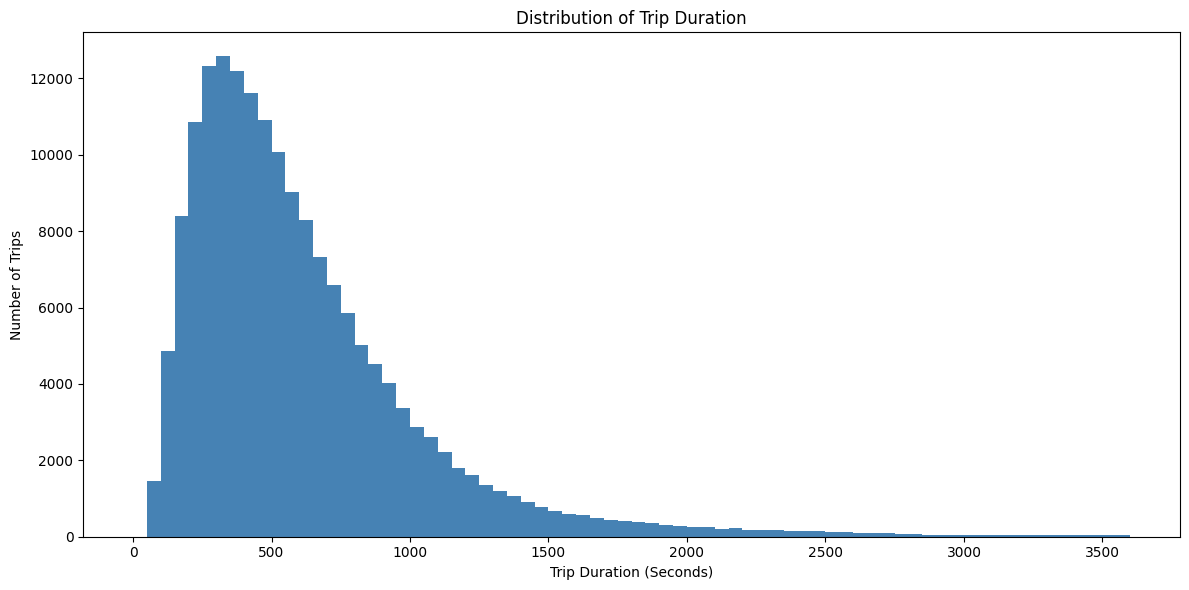

In [8]:
plt.figure(figsize=(12,6))

bike_duration = bike[bike['duration_sec'] <= 3600]

bins = np.arange(0,3600+50,50)

plt.hist(bike_duration['duration_sec'], bins=bins, color='steelblue')

plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (Seconds)')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

## (Visualization 2)

> Customers generally take longer trips than Subscribers. Subscribers have more consistent trip durations, suggesting regular commuting behavior.

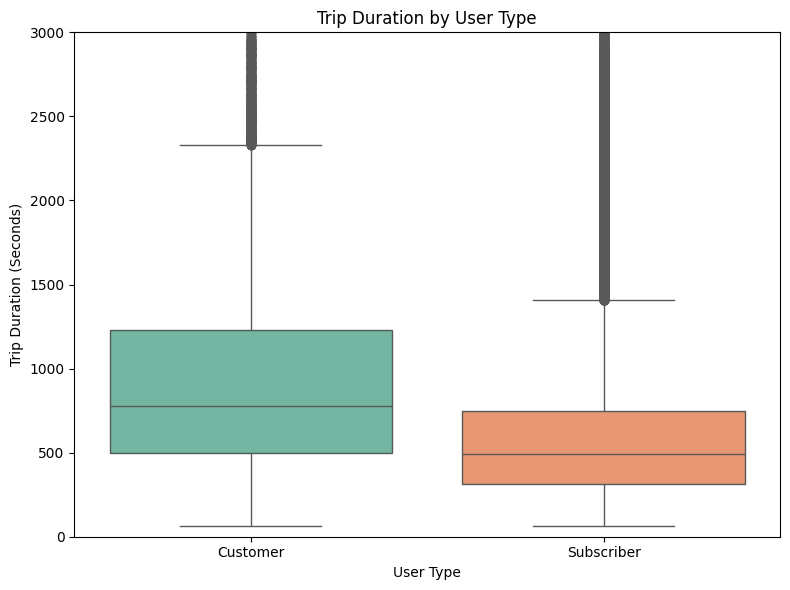

In [9]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=bike,
    x='user_type',
    y='duration_sec',
    palette='Set2'
)

plt.ylim(0,3000)

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (Seconds)')

plt.tight_layout()
plt.show()

## (Visualization 3)

> Younger riders make slightly longer trips on average. Subscribers dominate all age groups, and age has only a weak effect on trip duration.

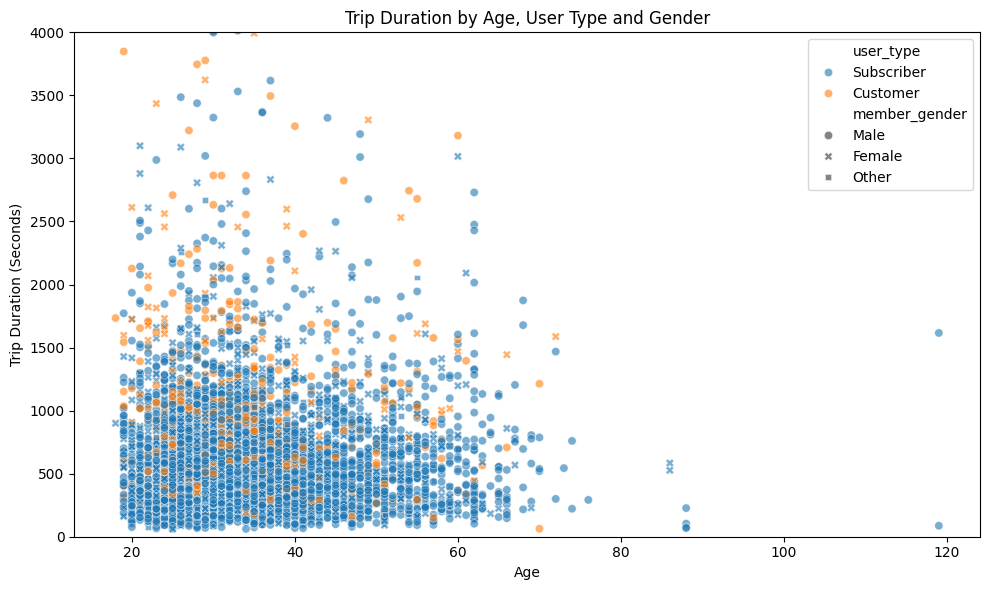

In [10]:
plt.figure(figsize=(10,6))

sample = bike.sample(6000, random_state=42)

sns.scatterplot(
    data=sample,
    x='age',
    y='duration_sec',
    hue='user_type',
    style='member_gender',
    alpha=0.6
)

plt.ylim(0,4000)

plt.title('Trip Duration by Age, User Type and Gender')
plt.xlabel('Age')
plt.ylabel('Trip Duration (Seconds)')

plt.tight_layout()
plt.show()